In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
%matplotlib inline
import matplotlib.gridspec as gridspec
from matplotlib.gridspec import GridSpec

import seaborn as sns

#Plotly
#Plotly
import plotly.express as px
import plotly.graph_objs as go
import plotly.figure_factory as ff

#Some styling
sns.set_style("darkgrid")
plt.style.use("fivethirtyeight")

import plotly.io as pio
pio.templates.default = "gridon"

#Subplots
from plotly.subplots import make_subplots

In [2]:
df = pd.read_csv("WA_Fn-UseC_-HR-Employee-Attrition.csv")

In [3]:
#First 5 rows of our dataset
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [4]:
df.shape

(1470, 35)

our dataset consists of **1470 columns** and **35 rows**

In [5]:
#Columns in our dataset
df.columns

Index(['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department',
       'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount',
       'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate',
       'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction',
       'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked',
       'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating',
       'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel',
       'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance',
       'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager'],
      dtype='object')

In [6]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,1470.0,36.923810,9.135373,18.0,30.00,36.0,43.00,60.0
DailyRate,1470.0,802.485714,403.509100,102.0,465.00,802.0,1157.00,1499.0
DistanceFromHome,1470.0,9.192517,8.106864,1.0,2.00,7.0,14.00,29.0
Education,1470.0,2.912925,1.024165,1.0,2.00,3.0,4.00,5.0
EmployeeCount,1470.0,1.000000,0.000000,1.0,1.00,1.0,1.00,1.0
EmployeeNumber,1470.0,1024.865306,602.024335,1.0,491.25,1020.5,1555.75,2068.0
EnvironmentSatisfaction,1470.0,2.721769,1.093082,1.0,2.00,3.0,4.00,4.0
HourlyRate,1470.0,65.891156,20.329428,30.0,48.00,66.0,83.75,100.0
JobInvolvement,1470.0,2.729932,0.711561,1.0,2.00,3.0,3.00,4.0
JobLevel,1470.0,2.063946,1.106940,1.0,1.00,2.0,3.00,5.0


In [7]:
#Information of dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

# Dataset Data Types Overview

- Our dataset contains two main data types:
1. **Integer** (`int`)  
2. **Object** (`object`)

- **Numerical features:** **26**  
- **Categorical features:** **9**
- Some features should be of object data type
- like  ```Education``` , ```EnvironmentSatisfaction```, ```JobInvolvement```, ```JobSatisfaction```, ```PerformanceRating```, ```RelationshipSatisfaction```, ```WorkLifeBalance``` 

In [8]:
df.skew()

C:\Users\alaqsa\AppData\Local\Temp\ipykernel_13972\1665899112.py:1: FutureWarning: The default value of numeric_only in DataFrame.skew is deprecated. In a future version, it will default to False. In addition, specifying 'numeric_only=None' is deprecated. Select only valid columns or specify the value of numeric_only to silence this warning.
  df.skew()


Age                         0.413286
DailyRate                  -0.003519
DistanceFromHome            0.958118
Education                  -0.289681
EmployeeCount               0.000000
EmployeeNumber              0.016574
EnvironmentSatisfaction    -0.321654
HourlyRate                 -0.032311
JobInvolvement             -0.498419
JobLevel                    1.025401
JobSatisfaction            -0.329672
MonthlyIncome               1.369817
MonthlyRate                 0.018578
NumCompaniesWorked          1.026471
PercentSalaryHike           0.821128
PerformanceRating           1.921883
RelationshipSatisfaction   -0.302828
StandardHours               0.000000
StockOptionLevel            0.968980
TotalWorkingYears           1.117172
TrainingTimesLastYear       0.553124
WorkLifeBalance            -0.552480
YearsAtCompany              1.764529
YearsInCurrentRole          0.917363
YearsSinceLastPromotion     1.984290
YearsWithCurrManager        0.833451
dtype: float64

In [9]:
features_to_change = [ 'Education' , 'EnvironmentSatisfaction', 'JobInvolvement', 'JobSatisfaction', 'PerformanceRating', 'RelationshipSatisfaction', 'WorkLifeBalance',
'StockOptionLevel', 'JobLevel', 'BusinessTravel','Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'OverTime']

int_to_object = ['Education' , 'EnvironmentSatisfaction', 'JobInvolvement', 'JobSatisfaction', 'PerformanceRating', 'RelationshipSatisfaction', 'WorkLifeBalance']

for feature in int_to_object:
    df[feature] = df[feature].astype(object)

# Feature to be examined for potential dropping

In [10]:
df['EmployeeCount'].value_counts()

1    1470
Name: EmployeeCount, dtype: int64

In [11]:
df['Over18'].value_counts()

Y    1470
Name: Over18, dtype: int64

In [12]:
df['EmployeeNumber'].value_counts()

1       1
1391    1
1389    1
1387    1
1383    1
       ..
659     1
657     1
656     1
655     1
2068    1
Name: EmployeeNumber, Length: 1470, dtype: int64

- This feature looks like an ID feature

In [13]:
df['StandardHours'].value_counts()

80    1470
Name: StandardHours, dtype: int64

- I think none of the above features added any value, so I will drop them.

In [14]:
features_to_drop=['StandardHours', 'EmployeeNumber', 'Over18', 'EmployeeCount']

for feature in features_to_drop :
    df.drop(columns=[feature],axis=1,inplace=True)

# Null values

In [15]:
df.isna().sum().sum()

0

# Target Feature

In [16]:
df['Attrition'].describe().T

count     1470
unique       2
top         No
freq      1233
Name: Attrition, dtype: object

In [26]:
# Attrition rate + pie
attrition_counts = df['Attrition'].value_counts()
attrition_rate = round(attrition_counts['Yes'] / len(df) * 100, 1)
print(f"Attrition Rate: {attrition_rate}%")

fig = make_subplots(rows=1, cols=2,
                    subplot_titles=("Count", "Proportion"),
                    specs=[[{"type": "bar"}, {"type": "pie"}]])

fig.add_trace(go.Bar(x=attrition_counts.index, y=attrition_counts.values,
                     marker_color=['blue', 'red']), row=1, col=1)
fig.add_trace(go.Pie(labels=attrition_counts.index, values=attrition_counts.values,
                     hole=0.4), row=1, col=2)
fig.update_layout(title=f"Attrition Distribution — {attrition_rate}% churned", showlegend=False)
fig.show()

Attrition Rate: 16.1%


- The dataset is clearly **imbalanced** — **83.9%** of employees stayed while only **16.1%** left, This imbalance can bias model performance, as a naive classifier could just predict "No" and still get 84% accuracy.

- Therefore, handling class imbalance ( using SMOTE or class weighting) is necessary for reliable modeling.

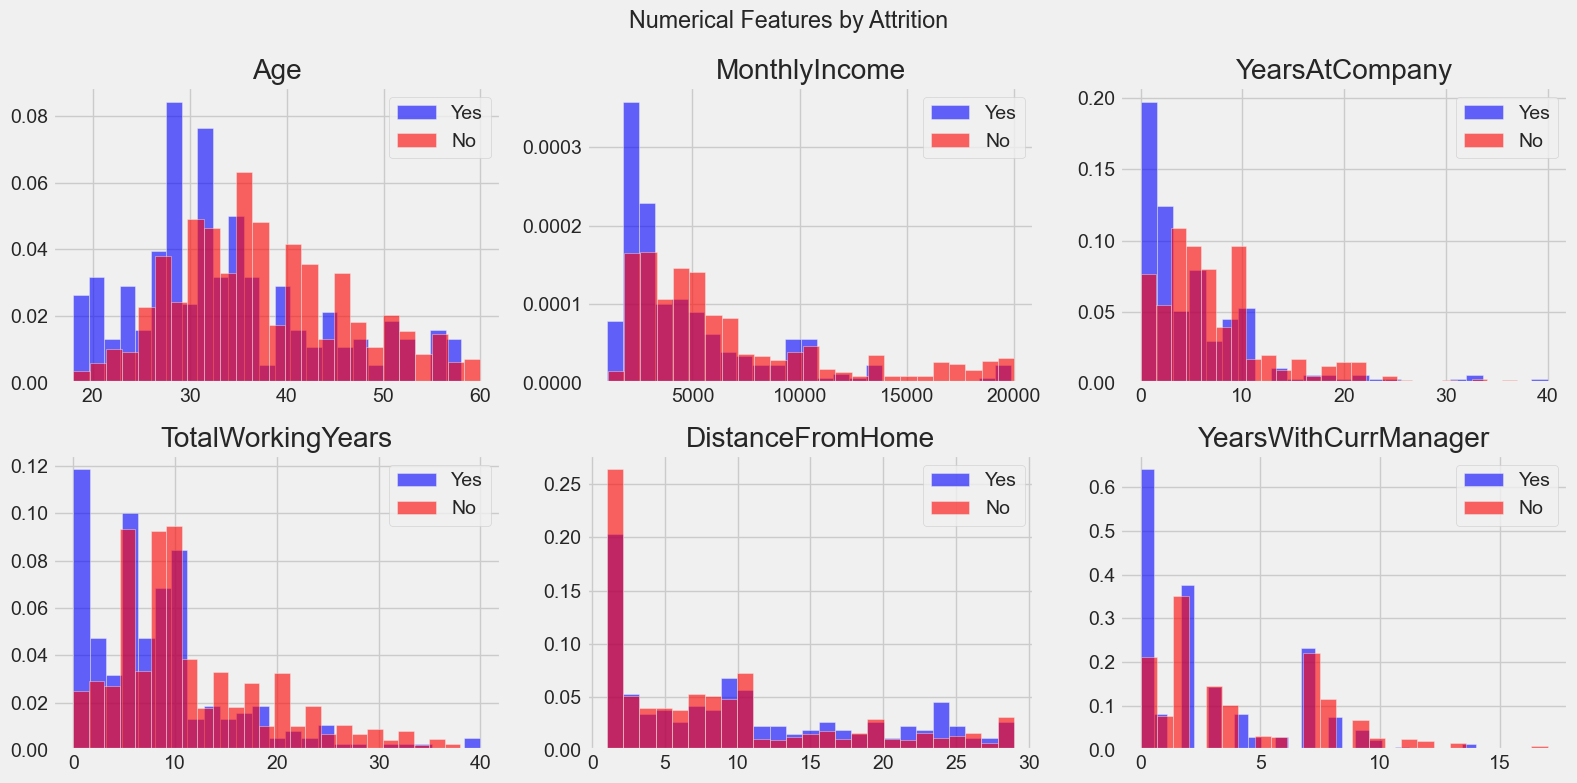

In [27]:
num_cols = ['Age', 'MonthlyIncome', 'YearsAtCompany', 'TotalWorkingYears',
            'DistanceFromHome', 'YearsWithCurrManager']

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    for label, color in zip(['Yes', 'No'], ['blue', 'red']):
        subset = df[df['Attrition'] == label][col]
        axes[i].hist(subset, bins=25, alpha=0.6, color=color, label=label, density=True)
    axes[i].set_title(col)
    axes[i].legend()

plt.suptitle("Numerical Features by Attrition")
plt.tight_layout()
plt.show()

- **Age**: Employees who left are mostly younger **(peak around 25–30)**, while those who stayed are more spread across **30–45. Early career employees are higher risk.**

- **MonthlyIncome**: Most employees who **left** earn **lower salaries (below $5k)**. Employees with **higher income rarely leave**, so income is an important factor for retention.

- **YearsAtCompany**: Employees who **left** usually have **short tenure**, mostly less than **5 years**. The first **1–3 years** seem to be the most important period.

- **TotalWorkingYears**: **Less experienced** employees are more likely to leave. Attrition **decreases a lot after 10+ years** of experience.

- **DistanceFromHome**: Employees who left tend to live a bit farther from work, but the effect is not very strong.

- **YearsWithCurrManager**: Employees who left spent **less time with their manager**, which suggests that having a stable manager helps keep employees.

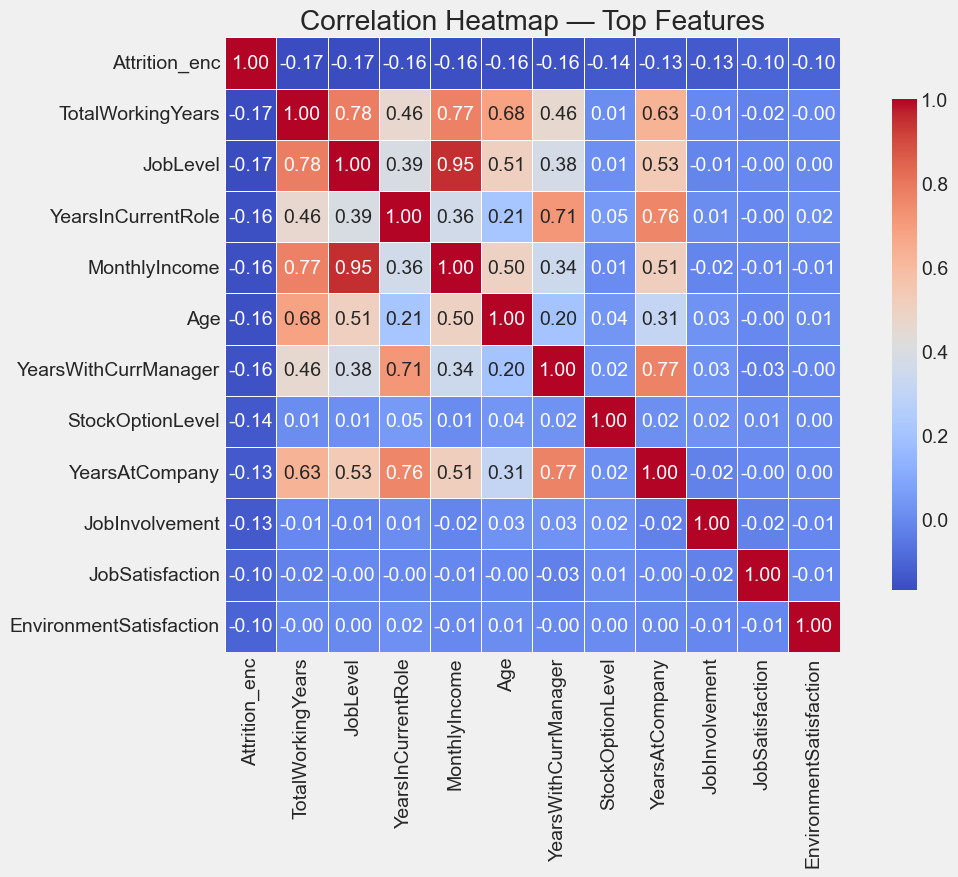

In [28]:
# Encode target for correlation
df_corr = df.copy()
df_corr['Attrition_enc'] = (df['Attrition'] == 'Yes').astype(int)

num_df = df_corr.select_dtypes(include='number')
corr = num_df.corr()

# Show only top features correlated with Attrition
top_corr_features = corr['Attrition_enc'].abs().sort_values(ascending=False).head(12).index
corr_top = num_df[top_corr_features].corr()

plt.figure(figsize=(12, 9))
sns.heatmap(corr_top, annot=True, fmt=".2f", cmap="coolwarm",
            linewidths=0.5, square=True, cbar_kws={"shrink": 0.8})
plt.title("Correlation Heatmap — Top Features")
plt.tight_layout()
plt.show()

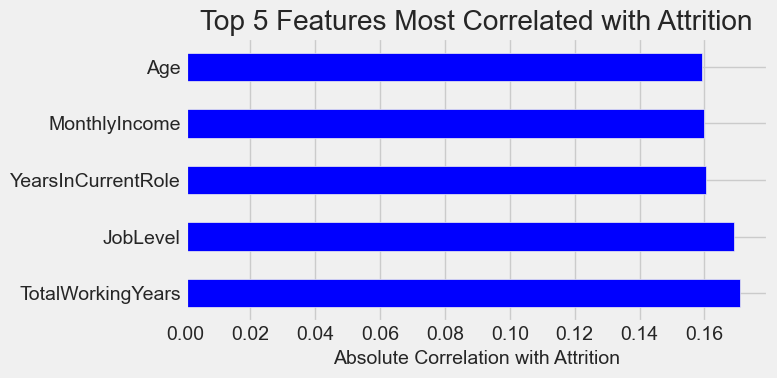

In [30]:
top5 = corr['Attrition_enc'].drop('Attrition_enc').abs().nlargest(5)

plt.figure(figsize=(8, 4))
top5.plot(kind='barh', color='blue')
plt.xlabel("Absolute Correlation with Attrition")
plt.title("Top 5 Features Most Correlated with Attrition")
plt.tight_layout()
plt.show()

- All top 5 features (TotalWorkingYears, JobLevel, YearsInCurrentRole, MonthlyIncome, Age) move in the same direction, as they all represent experience and seniority. This shows a clear pattern: **junior, less experienced, and lower-paid employees are more likely to leave**.

- The correlations are moderate (around 0.16–0.17), which means **no single feature is the main driver**. Instead, attrition is influenced by a combination of factors rather than one factor alone.

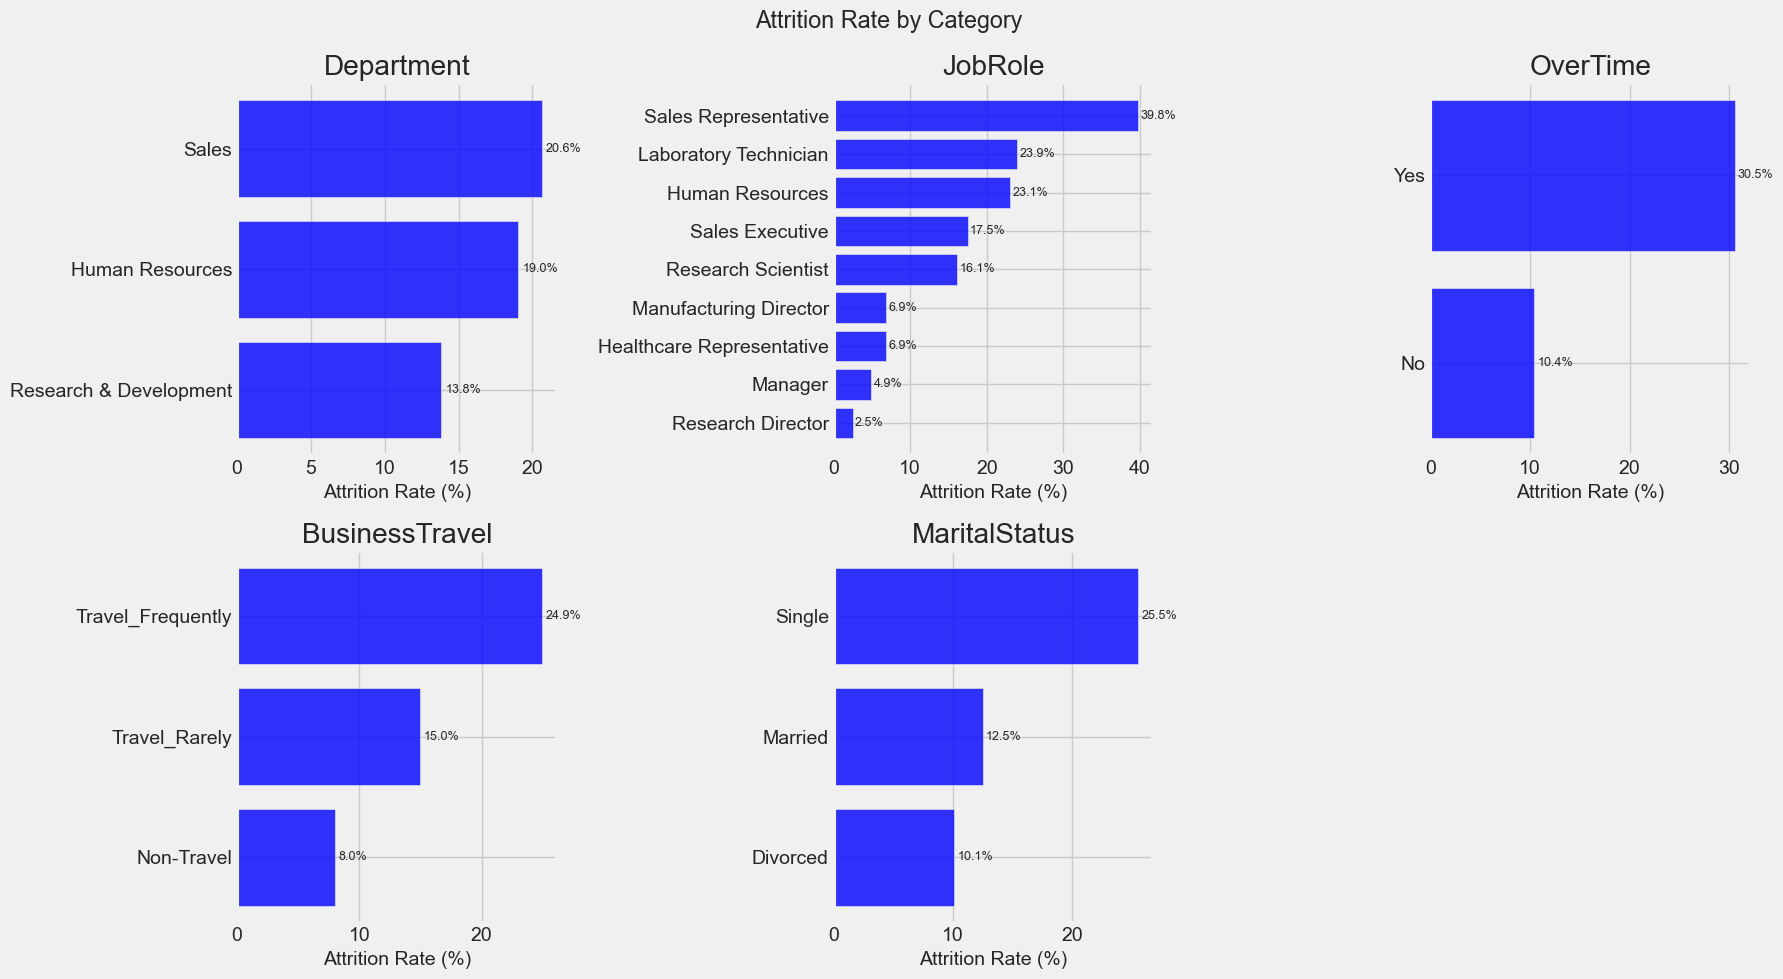

In [31]:
cat_cols = ['Department', 'JobRole', 'OverTime', 'BusinessTravel', 'MaritalStatus']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    rate = df.groupby(col)['Attrition'].apply(lambda x: (x == 'Yes').mean() * 100).sort_values()
    axes[i].barh(rate.index, rate.values, color='blue', alpha=0.8)
    axes[i].set_xlabel("Attrition Rate (%)")
    axes[i].set_title(col)
    for j, v in enumerate(rate.values):
        axes[i].text(v + 0.3, j, f"{v:.1f}%", va='center', fontsize=9)

axes[-1].set_visible(False)
plt.suptitle("Attrition Rate by Category")
plt.tight_layout()
plt.show()

- **OverTime**: Employees who work overtime have **almost 3× higher attrition (30.5% vs 10.4%)**, making it one of the strongest factors in the dataset.
  
- **JobRole**: **Sales Representatives have the highest attrition (39.8%)**, followed by Lab Technicians (23.9%) and HR (23.1%). **Research Directors have the lowest rate at 2.5%.**

- **BusinessTravel**: Employees who travel frequently have higher attrition (24.9%) compared to non-travelers (8%), showing that travel affects retention.

- **MaritalStatus**: **Single employees leave more often (25.5%) compared to divorced employees (10.1%),** possibly due to fewer personal commitments.

- **Department:** The Sales department has the highest attrition (20.6%), which matches the high attrition seen in Sales roles.

In [32]:
# Average satisfaction scores: Attrited vs Stayed
sat_cols = ['JobSatisfaction', 'EnvironmentSatisfaction',
            'RelationshipSatisfaction', 'WorkLifeBalance', 'JobInvolvement']

# Convert back to int for mean calculation
for c in sat_cols:
    df[c] = df[c].astype(int)

sat_means = df.groupby('Attrition')[sat_cols].mean()

fig = go.Figure()
for label, color in zip(['Yes', 'No'], ['red', 'blue']):
    fig.add_trace(go.Bar(name=label, x=sat_cols, y=sat_means.loc[label],
                         marker_color=color, opacity=0.8))

fig.update_layout(barmode='group',
                  title="Avg Satisfaction Scores: Attrited vs Stayed",
                  yaxis_title="Score (1–4)", xaxis_title="")
fig.show()

- Employees who left have lower scores in all 5 satisfaction measures. The biggest differences appear in JobSatisfaction and EnvironmentSatisfaction, where their scores are clearly lower.

- Even though the differences seem small (about 0.2–0.3 on a 1–4 scale), they are consistent across all metrics. There is no satisfaction area where employees who left scored the same or higher.

- This shows that dissatisfaction is not caused by one specific factor, but is a general feeling across multiple areas.

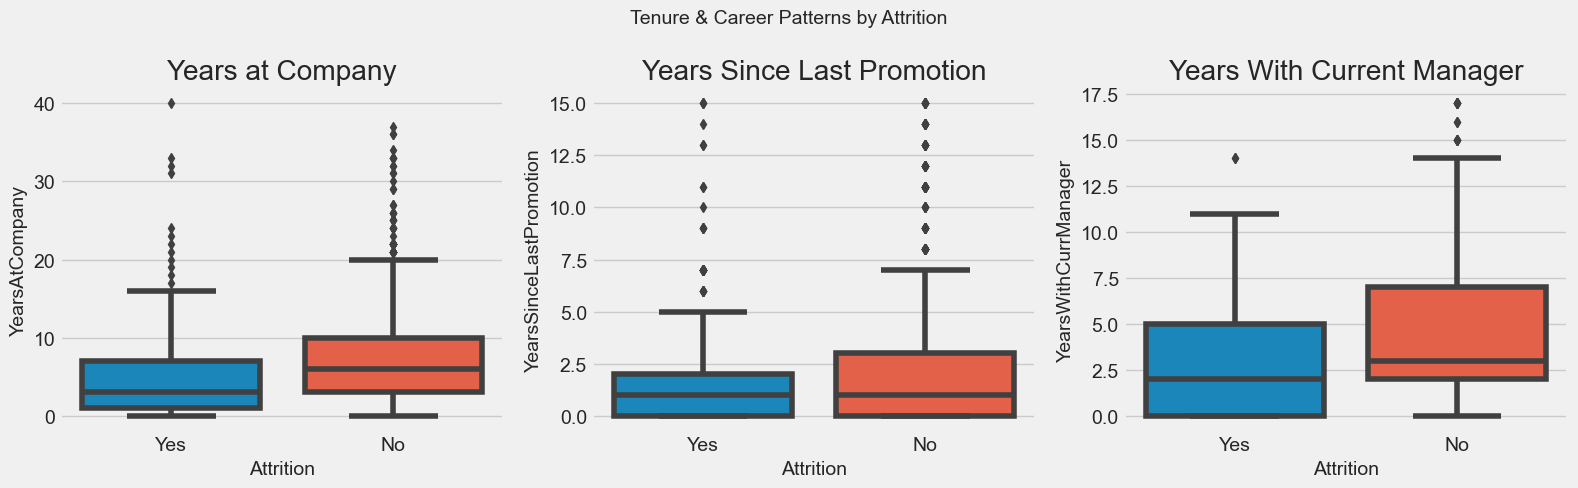

In [33]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Years at company
sns.boxplot(data=df, x='Attrition', y='YearsAtCompany', ax=axes[0])
axes[0].set_title("Years at Company")

# Years since last promotion
sns.boxplot(data=df, x='Attrition', y='YearsSinceLastPromotion', ax=axes[1])
axes[1].set_title("Years Since Last Promotion")

# Years with current manager
sns.boxplot(data=df, x='Attrition', y='YearsWithCurrManager', ax=axes[2])
axes[2].set_title("Years With Current Manager")


plt.suptitle("Tenure & Career Patterns by Attrition", fontsize=14)
plt.tight_layout()
plt.show()

- **Years at Company**: Employees who left stayed for a shorter time (around 3 years) compared to those who stayed (around 7 years). The first few years are the most risky.

- **Years Since Last Promotion**: **Both groups look similar**, with **low median values**. This suggests that **promotion alone is not the main reason employees leave**.

- **Years With Current Manager**: Employees who left spent less time with their manager. **A short relationship with the manager may indicate a new or unstable team**, or that employees leave before building strong connections — both are warning signs for HR.